# Task 2: Predict Future Stock Prices (Short-Term) 
Objective: <br>
 Use historical stock data to predict the next day's closing price. <br>
Dataset: <br>
 Stock market data from Yahoo Finance (retrieved using the yfinance Python library) <br>
Instructions:<br> 
● Select a stock (e.g., Apple, Tesla). <br>
● Load historical data using the yfinance library. <br>
● Use features like Open, High, Low, and Volume to predict the next Close price. <br>
● Train a Linear Regression or Random Forest model. <br>
● Plot actual vs predicted closing prices for comparison. <br>
Skills: <br>
● Time series data handling <br>
● Regression modeling <br>
● Data fetching using APIs (yfinance) <br>
● Plotting predictions vs real data<br>

# Install librarys

In [1]:
# !pip install yfinance

In [2]:
import yfinance as yf

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

# Downloading Historical Data

In [5]:
stock = yf.download("AAPL", start="2018-01-01", end="2024-01-01")

[*********************100%***********************]  1 of 1 completed


In [6]:
stock.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.304176,40.313537,39.602258,39.812835,102223600
2018-01-03,40.297161,40.839980,40.233991,40.367354,118071600
2018-01-04,40.484333,40.587282,40.262059,40.369685,89738400
2018-01-05,40.945267,41.031836,40.489020,40.580269,94640000
2018-01-08,40.793182,41.087987,40.694911,40.793182,82271200


In [7]:
stock.shape

(1509, 5)

In [8]:
stock.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1509.000000,1509.000000,1509.000000,1509.000000,1.509000e+03
mean,107.723608,108.850195,106.484612,107.623747,1.073284e+08
std,50.886479,51.359839,50.359434,50.845543,5.513287e+07
min,33.768078,34.606402,33.722955,34.193175,2.404830e+07
25%,51.189526,51.991795,50.810872,51.326787,7.078370e+07
50%,120.352119,121.604993,118.854387,120.492781,9.296430e+07
75%,150.080338,151.830427,148.084685,149.906081,1.280440e+08
max,196.073105,197.567574,194.974519,195.984034,4.265100e+08


In [9]:
stock.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

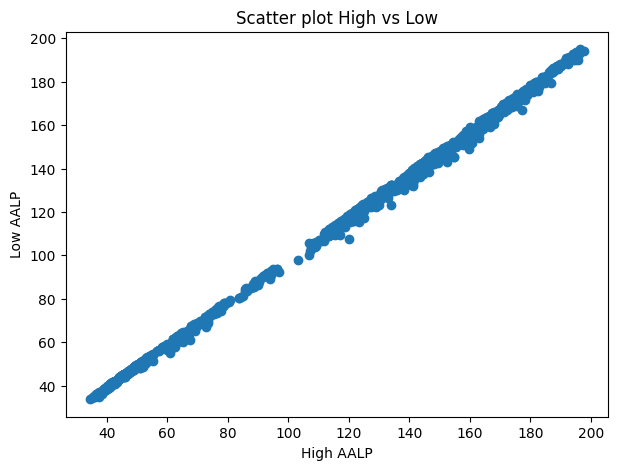

In [10]:
plt.figure(figsize=(7,5))
plt.scatter(x=stock["High"] , y=stock["Low"])
plt.title("Scatter plot High vs Low")
plt.xlabel("High AALP")
plt.ylabel("Low AALP")
plt.show()

# Independdent and Dependent Features

In [11]:
# Takes columns High , Open , Low and Volumne
X = stock.iloc[: , 1:]

In [12]:
X

Price,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL
Date,,,,
2018-01-02,40.313537,39.602258,39.812835,102223600
2018-01-03,40.839980,40.233991,40.367354,118071600
2018-01-04,40.587282,40.262059,40.369685,89738400
2018-01-05,41.031836,40.489020,40.580269,94640000
2018-01-08,41.087987,40.694911,40.793182,82271200
...,...,...,...,...
2023-12-22,193.400854,190.985939,193.173208,37149600
2023-12-26,191.896500,190.847401,191.619380,28919300


In [13]:
y = stock["Close"]

In [14]:
y

Ticker,AAPL
Date,
2018-01-02,40.304176
2018-01-03,40.297161
2018-01-04,40.484333
2018-01-05,40.945267
2018-01-08,40.793182
...,...
2023-12-22,191.609467
2023-12-26,191.065140
2023-12-27,191.164093


# Split train and test data 

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size=20 , random_state=42
)

# Traning Regression Model 

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
liner_model = LinearRegression()

In [19]:
liner_model.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
from sklearn.metrics import r2_score

# Accuracy at traning data

In [24]:
y_pred = liner_model.predict(X_train)

In [25]:
score = r2_score(y_pred , y_train)
score

0.9997654302997583

# Accuracy at test data

In [30]:
y_pred = liner_model.predict(X_test)

In [31]:
score = r2_score(y_pred , y_test)
score

0.9997748244906568

In [34]:
y_pred.shape

(20, 1)

In [35]:
X_test

Price,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL
Date,,,,
2020-04-21,66.990762,64.134743,66.756385,180991600
2022-07-22,153.345722,150.529613,152.472433,66675400
2019-07-11,48.935584,48.293933,48.677007,80767200
2020-04-28,69.063929,67.220330,68.882710,112004800
2021-11-02,148.100814,145.247635,145.257416,69122000
2022-08-31,157.783839,154.403737,157.518536,87991100
2018-09-12,53.248473,52.027307,53.234274,197114800
2022-04-22,164.476409,158.235187,163.094924,84882400


# Plot actual vs predicted closing prices

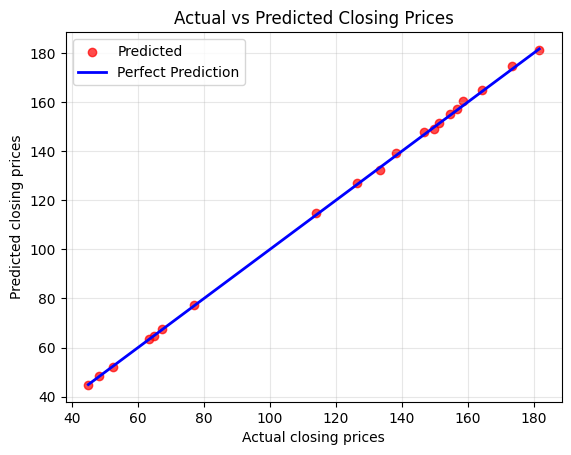

In [48]:
plt.scatter(y_test, y_pred, c="red", alpha=0.7, label="Predicted") 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'blue', lw=2, label="Perfect Prediction")  
plt.xlabel("Actual closing prices")
plt.ylabel("Predicted closing prices")
plt.title("Actual vs Predicted Closing Prices")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [49]:
# Traning Random forest Model 

In [50]:
from sklearn.ensemble import RandomForestRegressor

In [53]:
rfr_model = RandomForestRegressor()

In [54]:
rfr_model.fit(X_train , y_train)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Accuracy at traning data

In [55]:
y_pred = rfr_model.predict(X_train)

In [56]:
score = r2_score(y_pred , y_train)
score

0.9999424380581866

# Accuracy at test data

In [57]:
y_pred = liner_model.predict(X_test)

In [58]:
score = r2_score(y_pred , y_test)
score

0.9997748244906568

# Plot actual vs predicted closing prices

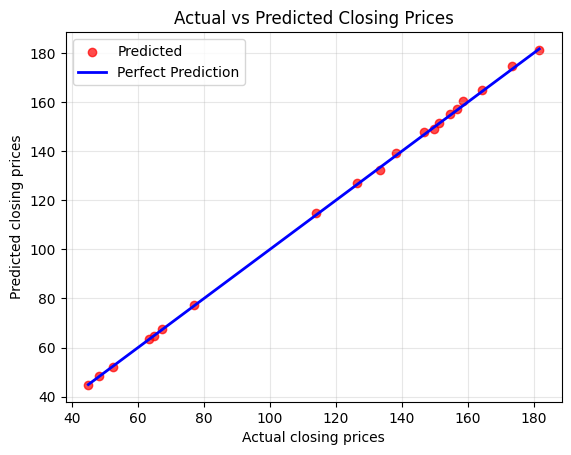

In [59]:
plt.scatter(y_test, y_pred, c="red", alpha=0.7, label="Predicted") 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'blue', lw=2, label="Perfect Prediction")  
plt.xlabel("Actual closing prices")
plt.ylabel("Predicted closing prices")
plt.title("Actual vs Predicted Closing Prices")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()